<a href="https://colab.research.google.com/github/AFK-Kuntal/MNIST-DigitClassification/blob/main/Digit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
tf.__version__

'2.20.0'

In [3]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
def load_data_and_preprocess():
  (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
  X_train = X_train.astype('float32') / 255.0
  X_test = X_test.astype('float32') / 255.0
  X_train = np.expand_dims(X_train, -1)
  X_test = np.expand_dims(X_test, -1)
  return (X_train, y_train), (X_test, y_test)

In [5]:
(X_train, y_train), (X_test, y_test) = load_data_and_preprocess()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
print(type(X_train))
X_train

<class 'numpy.ndarray'>


array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = SEED)

In [8]:
print(f"the shape of the train set is {X_train.shape}")
print(f"the shape of the val set is {X_val.shape}")
print(f"the shape of the test set is {X_test.shape}")

the shape of the train set is (48000, 28, 28, 1)
the shape of the val set is (12000, 28, 28, 1)
the shape of the test set is (10000, 28, 28, 1)


In [9]:
def plot_digits(X, y):
  for i in range(20):
    idx = np.random.randint(0, len(X))
    plt.subplot(4, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap = 'grey')
    plt.title(f"Digit: {y[i]}")
    plt.axis('off')
    plt.tight_layout()
  plt.show()

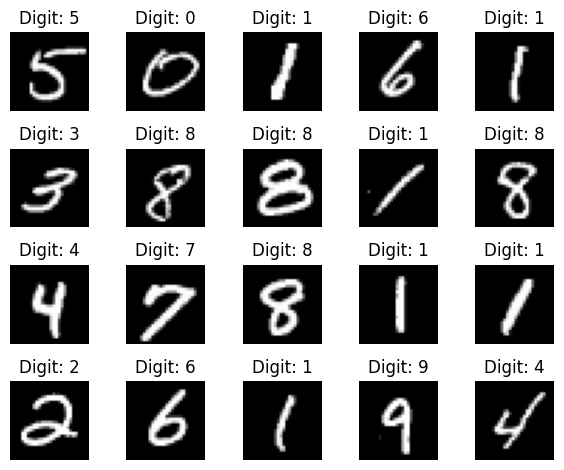

In [10]:
plot_digits(X_train, y_train)

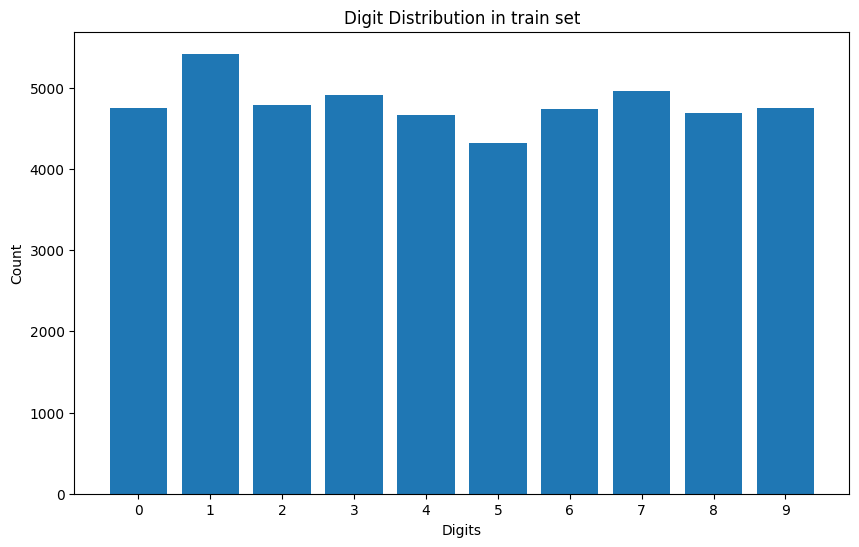

In [11]:
unique_labels, counts = np.unique(y_train, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels, counts)
plt.xticks(unique_labels)
plt.xlabel("Digits")
plt.ylabel("Count")
plt.title("Digit Distribution in train set")
plt.show()

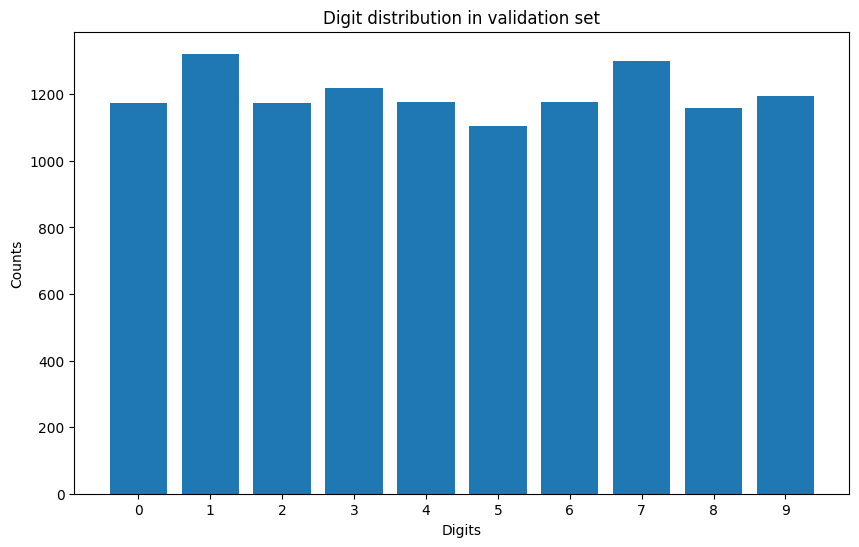

In [12]:
unique_labels_val, counts_val = np.unique(y_val, return_counts = True)
plt.figure(figsize = (10, 6))
plt.bar(unique_labels_val, counts_val)
plt.xticks(unique_labels_val)
plt.xlabel("Digits")
plt.ylabel("Counts")
plt.title("Digit distribution in validation set")
plt.show()

In [13]:
from keras import Sequential
from keras.layers import *

In [14]:
InputSize = X_train[0].shape
Batch = 32
Epochs = 15

In [15]:
model = Sequential([
    layers.Input(shape = InputSize),

    layers.Conv2D(32, (3,3), 1, padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), 1, activation = 'relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, 3, 1, activation = 'relu'),
    layers.MaxPooling2D(2),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(len(unique_labels), 'softmax')
])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,138 (656.79 KB)

 Trainable params: 167,690 (655.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [18]:
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = 'TRUE'),
    keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', patience = 3, min_lr = 1e-6)
]

In [19]:
history = model.fit(
    X_train, y_train,
    batch_size = Batch,
    epochs = Epochs,
    validation_data = (X_val, y_val),
    callbacks = my_callbacks
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9152 - loss: 0.2788 - val_accuracy: 0.9829 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9722 - loss: 0.0996 - val_accuracy: 0.9865 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9797 - loss: 0.0738 - val_accuracy: 0.9875 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9809 - loss: 0.0697 - val_accuracy: 0.9855 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9842 - loss: 0.0548 - val_accuracy: 0.9886 - val_loss: 0.0460 - learning_rate: 0.0010


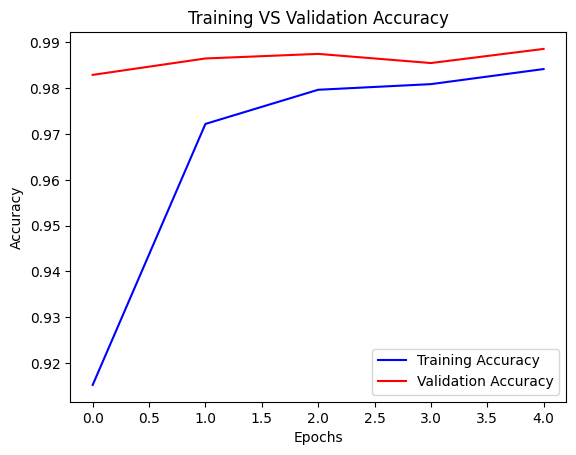

In [23]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy', color = 'blue')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy', color = 'red')
plt.title("Training VS Validation Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

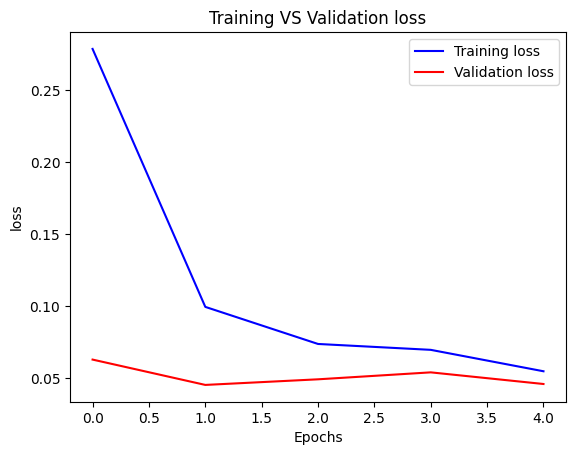

In [22]:
plt.plot(history.history['loss'], label = 'Training loss', color = 'blue')
plt.plot(history.history['val_loss'], label = 'Validation loss', color = 'red')
plt.title("Training VS Validation loss")
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()